# Agglomerative (Hierarchical) Clustering

## Table of Contents

### 1. What is Agglomerative Clustering?

### 2. Agglomerative Clustering in Scikit-Learn

### 3. Evaluation of Clustering

### 4. Important Considerations for Agglomerative Clustering

## 1. What is Agglomerative Clustering?

A hierarchical clustering method that builds a tree (dendrogram) of clusters.

“Agglomerative” means bottom-up:

- Start with each point as its own cluster

- Iteratively merge the two closest clusters

- Repeat until all points are merged into one cluster or a desired number of clusters is reached

Result: a dendrogram (tree diagram showing cluster merges)

Goal: Understand **hierarchical relationships** between data points.

**Unlike K-Means, it does not require random initialization, so results are deterministic given the same parameters**


## 2. Agglomerative Clustering in Scikit-Learn

The name of the class for Agglomerative Clustering in Scikit-Learn
  **sklearn.cluster.AgglomerativeClustering**


## **AgglomerativeClustering Parameters Explained (scikit-learn)**

### **Most Important Parameters**

### `1. n_clusters`
-  The number of clusters to form. Determines how many groups the algorithm will merge the points into.  
- default=2
- If you also set `distance_threshold`, this parameter is ignored because merging is stopped based on distance rather than cluster count.  

### `2.metric`

Distance metric used to calculate similarity between points. Determines which points are “close” to each other.

**Common Options:**  
  - `euclidean` (default) → straight-line distance; most common for numeric features.  
  - `manhattan` → sum of absolute differences; robust to outliers.  
  - `cosine` → measures angle between vectors; useful for text embeddings   

### `3. linkage`

Determines how the distance between **clusters** is computed during merging  

**Options**  

  - `ward` (default) → merges clusters that **minimize the variance** of combined cluster; produces compact, round clusters. Only works with Euclidean distance

  - `complete` → distance = **maximum distance** between any two points across clusters. Produces **tight, well-separated clusters**

  - `average` → distance = **average of all pairwise distances** between points in the two clusters. Balanced behavior between single and complete linkage

Different linkages affect **cluster shape, size and sensitivity to noise**  




**Important rules and constraints:**
- If `linkage="ward"`, **only `"euclidean"` is allowed**  
  (because Ward’s method relies on variance minimization).

Choice of metric affects which points are considered “close” and thus which clusters are merged first  


### **Occasionally Used Parameters**

### `distance_threshold`

Stops merging clusters when the distance between clusters exceeds this threshold.

**Options:** float (default=None)  

- Useful when you want a **hierarchy** and do not know the number of clusters in advance

- Example: `distance_threshold=5` → any clusters separated by more than 5 units will **not merge**, creating more clusters automatically

- If set, `n_clusters` is ignored  


### `compute_full_tree`

Determines whether the full clustering tree is computed. Needed for dendrogram plotting.  

**Options**  (default=auto)
  - `auto` → computes full tree only when needed (e.g., small datasets or dendrogram)
  - `True` → always compute the full tree; useful for plotting dendrograms  
  - `False` → skips computing full tree to save memory and computation for large datasets

### Apply Agglomerative Clustering to a simple Dataset

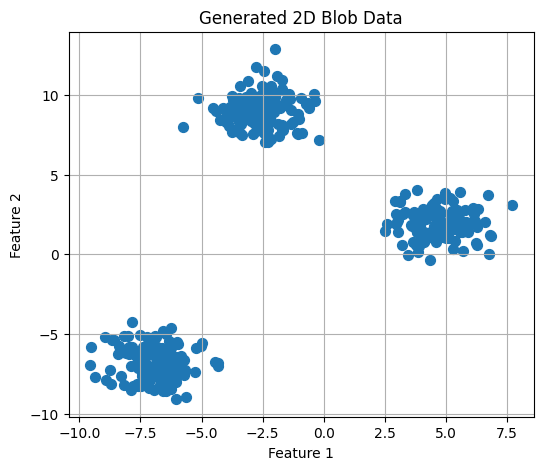

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import pandas as pd
from sklearn.metrics import silhouette_score

# Generate 400 points in 2D, 3 clusters
X, y = make_blobs(n_samples=400, n_features=2, centers=3, random_state=42)

# Plot the raw data
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Generated 2D Blob Data")
plt.grid(True)
plt.show()

Silhouette Score: 0.8458787585795497


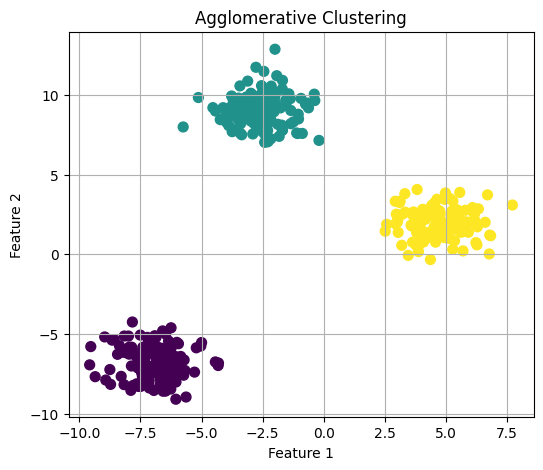

In [2]:
# Create the model
agg = AgglomerativeClustering(
    n_clusters=3,       # we know 3 clusters exist
    metric='euclidean',  # distance metric
    linkage='ward'          # linkage method
)

# Fit and predict cluster labels
labels = agg.fit_predict(X)
score = silhouette_score(X, labels)
print("Silhouette Score:", score)
# Plot clustered data
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Agglomerative Clustering")
plt.grid(True)
plt.show()

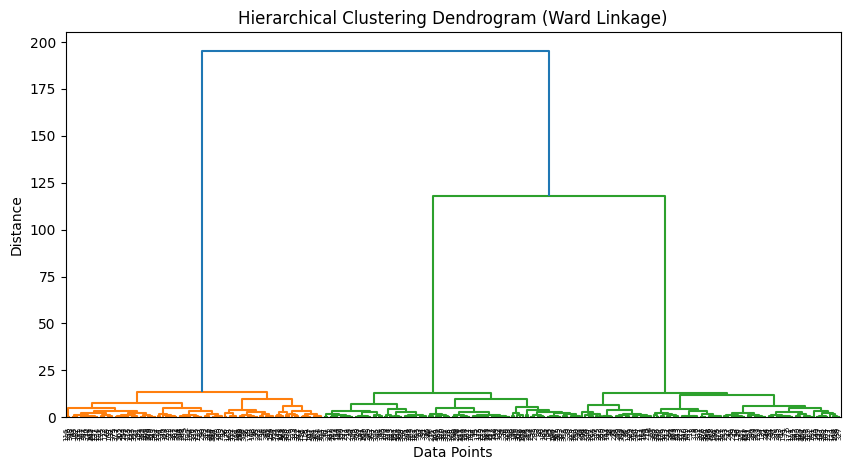

In [3]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(X, method='ward', metric='euclidean')

# Plot dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

#### How to Interpret the Dendrogram

- Each leaf → one data point

- Each merge → two clusters being combined

- The height of a merge → distance between clusters

#### Choosing the Number of Clusters

- Draw a horizontal line across the dendrogram

- Count how many vertical branches it cuts

### Rule of thumb:

Choose the cut where there is a large vertical gap
(big jump in distance before clusters merge)

## Important Considerations for Agglomerative Clustering

### When to Use Agglomerative Clustering

**- Does not require specifying K upfront:**  
Hierarchical clustering can build a full hierarchy of clusters and allows you to decide the number of clusters later by cutting the dendrogram at a chosen level.

**- Works well with small to medium datasets:**  
Because it computes distances between many pairs of points, it is more suitable when the dataset is not extremely large.

**- Useful for understanding data structure:**  
The dendrogram provides a visual explanation of how data points are grouped, making it useful for exploratory analysis.

**- Flexible cluster shapes (linkage):**  
Different linkage methods allow the algorithm to capture different types of cluster structures


### Limitations of Agglomerative Clustering

**- Computationally expensive:**  
Agglomerative clustering has higher time and memory complexity, making it impractical for very large datasets

**- Sensitive to noise and outliers:**  
Outliers can form their own clusters or distort the merging process

**- Early decisions cannot be undone:**  
Once two clusters are merged, the algorithm cannot reconsider that decision later, which may lead to suboptimal clusters

**- Results depend heavily on linkage choice:**  
Different linkage methods can produce very different clusterings, so parameter selection is critical

## Task 2A: Agglomerative Clustering

In this task, you will apply **Agglomerative Clustering** to `CC GENERAL` dataset and follow **the same methodology** used in the previous clustering lab

## **1. Exploratory Data Analysis (EDA)**

In [4]:
!pip install pandas numpy matplotlib seaborn scikit-learn scipy


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Qebaa\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd

df = pd.read_csv("CC GENERAL.csv")
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [6]:
df.shape

(8950, 18)

In [7]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [8]:
df.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

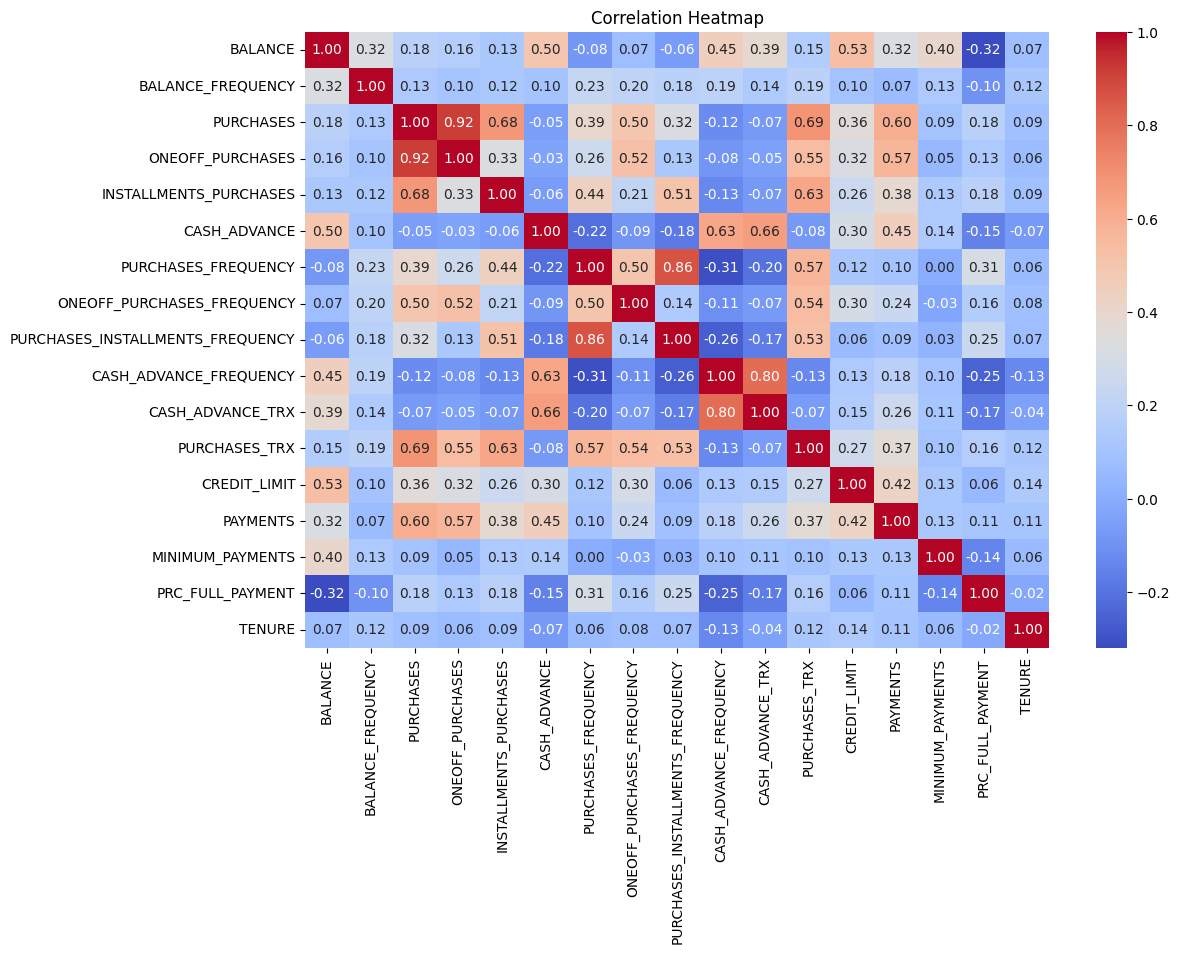

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## **2. Data Preparation**

In [10]:
df = df.drop("CUST_ID", axis=1)

In [11]:
df["CREDIT_LIMIT"] = df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].median())
df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].median())

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(df)
pd.DataFrame(X, columns=df.columns).head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960378,-0.528979,-0.302400,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688678,0.818642,0.097500,0.234227,0.36068
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826100,-0.383805,-0.093293,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826100,-0.598688,-0.228307,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905410,-0.364368,-0.257266,-0.525551,0.36068


## **3. Apply Agglomerative Clustering**

In [13]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

scores = []
k_values = [2, 3, 4, 5]

for k in k_values:
    model = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)
    print("k =", k, "  Silhouette Score =", round(score, 4))

k = 2   Silhouette Score = 0.1921
k = 3   Silhouette Score = 0.1674
k = 4   Silhouette Score = 0.1598
k = 5   Silhouette Score = 0.1763


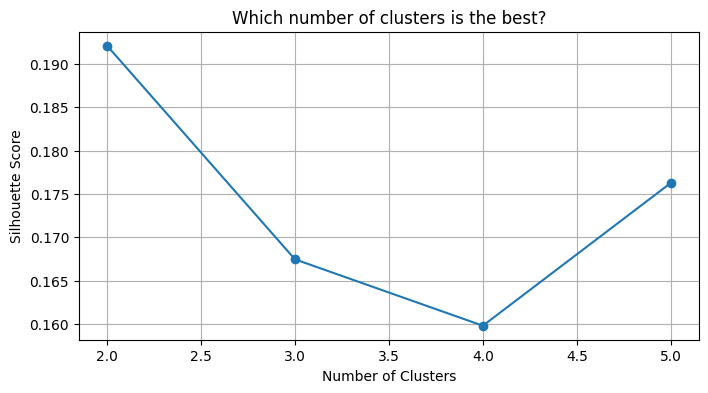

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(k_values, scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Which number of clusters is the best?")
plt.grid(True)
plt.show()

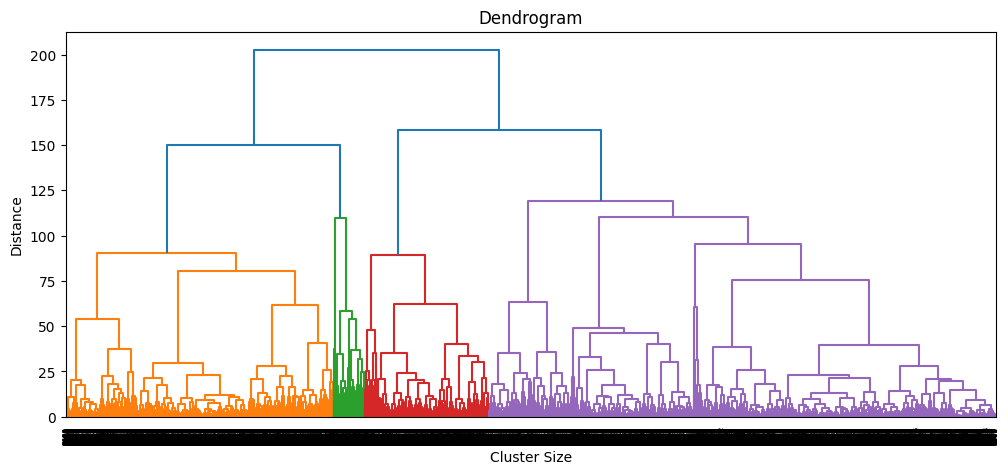

In [15]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X, method='ward', metric='euclidean')

plt.figure(figsize=(12, 5))
dendrogram(Z)
plt.title("Dendrogram")
plt.xlabel("Cluster Size")
plt.ylabel("Distance")
plt.show()

In [16]:
best_k = 2
print("Best k =", best_k)

model = AgglomerativeClustering(n_clusters=best_k, metric='euclidean', linkage='ward')
labels = model.fit_predict(X)

df["Cluster"] = labels
print(df["Cluster"].value_counts())

Best k = 2
Cluster
0    6069
1    2881
Name: count, dtype: int64


In [17]:
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,0
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,0
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,0
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12,0
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,0


## **4. Visualize the Clustering Results**

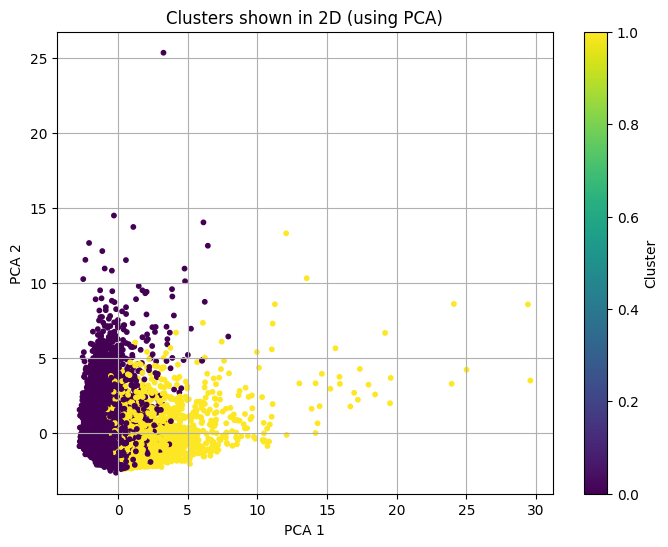

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=10)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Clusters shown in 2D (using PCA)")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()

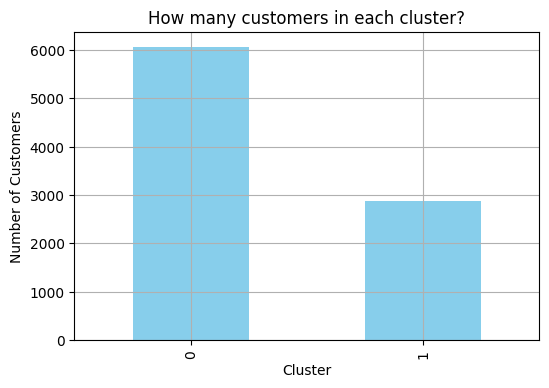

In [19]:
plt.figure(figsize=(6, 4))
df["Cluster"].value_counts().plot(kind='bar', color='skyblue')
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("How many customers in each cluster?")
plt.grid(True)
plt.show()

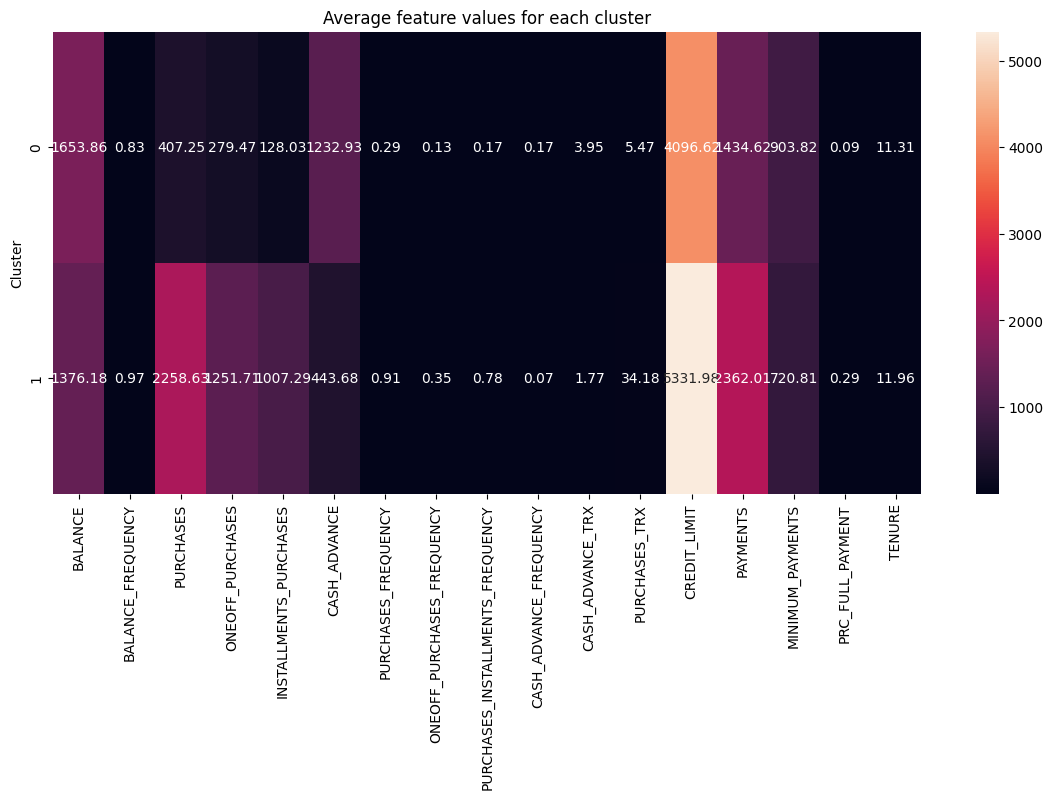

In [20]:
cluster_means = df.groupby("Cluster").mean()

plt.figure(figsize=(14, 6))
sns.heatmap(cluster_means, annot=True, fmt=".2f")
plt.title("Average feature values for each cluster")
plt.show()

## **5. Evaluate the Clustering**

In [21]:
score = silhouette_score(X, labels)
print("Silhouette Score:", round(score, 4))

Silhouette Score: 0.1921


In [22]:
model_ward = AgglomerativeClustering(n_clusters=best_k, metric='euclidean', linkage='ward')
labels_ward = model_ward.fit_predict(X)
score_ward = silhouette_score(X, labels_ward)
print("Ward linkage score:", round(score_ward, 4))

model_complete = AgglomerativeClustering(n_clusters=best_k, metric='euclidean', linkage='complete')
labels_complete = model_complete.fit_predict(X)
score_complete = silhouette_score(X, labels_complete)
print("Complete linkage score:", round(score_complete, 4))

model_average = AgglomerativeClustering(n_clusters=best_k, metric='euclidean', linkage='average')
labels_average = model_average.fit_predict(X)
score_average = silhouette_score(X, labels_average)
print("Average linkage score:", round(score_average, 4))

Ward linkage score: 0.1921
Complete linkage score: 0.7866
Average linkage score: 0.8408


In [23]:
cluster_means

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,1653.861262,0.834041,407.246187,279.474220,128.034951,1232.928852,0.291090,0.130452,0.165666,0.165775,3.952875,5.465810,4096.621945,1434.617983,903.815699,0.087254,11.309277
1,1376.176922,0.968336,2258.627612,1251.713096,1007.293058,443.683185,0.910106,0.354142,0.783160,0.070618,1.765706,34.182923,5331.978322,2362.006573,720.811553,0.293717,11.955571


## **6. Explain whether the clustering quality and justify your reasoning**

The silhouette score we got is around 0.19 which is on the weaker side (below 0.25). This means the clusters are not perfectly separated and there is some overlap between them.

When we tried different linkage methods, average and complete linkage gave much higher scores than ward. This means the way we measure distance between clusters matters a lot for the results.